# Yellow Taxi adat 2011

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
testYellow = Path('raw_data/2011/yellow_tripdata_2011-01.parquet')

In [3]:
if not testYellow.exists():
    raise FileNotFoundError(f'Not found: {testYellow.resolve()}')

trips_df = pd.read_parquet(testYellow)

print(f'Rows: {len(trips_df):,}')
print(f'Columns: {trips_df.shape[1]}')
trips_df.head()

Rows: 13,464,997
Columns: 19


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2011-01-01 00:10:00,2011-01-01 00:12:00,4,0.0,1,NaN,145,145,1,2.9,0.5,0.5,0.28,0.0,0.0,4.18,NaN,NaN
1,2,2011-01-01 00:04:00,2011-01-01 00:13:00,4,0.0,1,NaN,264,264,1,5.7,0.5,0.5,0.24,0.0,0.0,6.94,NaN,NaN
2,2,2011-01-01 00:14:00,2011-01-01 00:16:00,4,0.0,1,NaN,264,264,1,2.9,0.5,0.5,1.11,0.0,0.0,5.01,NaN,NaN
3,2,2011-01-01 00:04:00,2011-01-01 00:06:00,5,0.0,1,NaN,146,146,1,2.9,0.5,0.5,0.00,0.0,0.0,3.90,NaN,NaN
4,2,2011-01-01 00:08:00,2011-01-01 00:08:00,5,0.0,1,NaN,146,146,1,2.5,0.5,0.5,0.11,0.0,0.0,3.61,NaN,NaN


## Info

In [4]:
trips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13464997 entries, 0 to 13464996
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64 

## Compute Missing Value Ratio

In [5]:
# Percentage of missing values per column
missing_pct = trips_df.isna().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)

display(missing_pct.to_frame(name="missing_pct"))

,missing_pct
airport_fee,99.999993
congestion_surcharge,99.999993
store_and_fwd_flag,50.043375
tpep_dropoff_datetime,0.000000
tpep_pickup_datetime,0.000000
VendorID,0.000000
passenger_count,0.000000
PULocationID,0.000000
DOLocationID,0.000000
trip_distance,0.000000


## Drop Columns Above Threshold

In [6]:
missing_threshold = 40  # percentage

cols_to_drop = missing_pct[missing_pct > missing_threshold].index

print(f"Columns above {missing_threshold}% missing values:")
print(list(cols_to_drop))

trips_df = trips_df.drop(columns=cols_to_drop)

print(f"\nRemaining columns: {trips_df.shape[1]}")

Columns above 40% missing values:
['airport_fee', 'congestion_surcharge', 'store_and_fwd_flag']

Remaining columns: 16


## Check duplicate rows

In [7]:
dup_rows = trips_df.duplicated().sum()
print(f'Duplicate rows: {dup_rows:,}')

Duplicate rows: 112


## Remove duplicate rows

In [8]:
trips_df = trips_df.drop_duplicates()

dup_rows_after = trips_df.duplicated().sum()
print(f'Duplicate rows after cleaning: {dup_rows_after}')

Duplicate rows after cleaning: 0


## Data columns

In [9]:
trips_df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
dtype: object

## Canonical schema

In [10]:
# Columns we want to keep from the raw yellow taxi dataset
columns_to_keep = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'passenger_count',
    'trip_distance',
    'PULocationID',
    'DOLocationID',
]

trips_df = trips_df[columns_to_keep].copy()

rename_map = {
    'tpep_pickup_datetime': 'pickup_at',
    'tpep_dropoff_datetime': 'dropoff_at',
    'passenger_count': 'passenger_count',
    'trip_distance': 'trip_distance',
    'PULocationID': 'pickup_location_id',
    'DOLocationID': 'dropoff_location_id',
}

trips_df = trips_df.rename(columns=rename_map)

for c in ['pickup_at', 'dropoff_at']:
    if c in trips_df.columns:
        trips_df[c] = pd.to_datetime(trips_df[c], errors='coerce')

trips_df.info()

<class 'pandas.DataFrame'>
Index: 13464885 entries, 0 to 13464996
Data columns (total 6 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pickup_at            datetime64[us]
 1   dropoff_at           datetime64[us]
 2   passenger_count      int64         
 3   trip_distance        float64       
 4   pickup_location_id   int64         
 5   dropoff_location_id  int64         
dtypes: datetime64[us](2), float64(1), int64(3)
memory usage: 719.1 MB


## Typing

In [11]:
roles = {'datetime': [], 'categorical': [], 'discrete': [], 'continuous': []}

for col in trips_df.columns:
    s = trips_df[col]

    if pd.api.types.is_datetime64_any_dtype(s):
        roles['datetime'].append(col)
        continue

    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s) or pd.api.types.is_bool_dtype(s):
        roles['categorical'].append(col)
        continue

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        unique_n = non_null.nunique()

        is_int_like = pd.api.types.is_integer_dtype(s)
        if (not is_int_like) and len(non_null) > 0:
            sample = non_null.iloc[:50_000]
            is_int_like = np.all(np.isclose(sample.to_numpy(), np.round(sample.to_numpy())))

        if is_int_like and unique_n <= 200:
            roles['discrete'].append(col)
        else:
            roles['continuous'].append(col)
        continue

    roles['categorical'].append(col)

for role_name, cols in roles.items():
    print(f'{role_name}: {len(cols)} column')
    print(cols)


datetime: 2 column
['pickup_at', 'dropoff_at']
categorical: 0 column
[]
discrete: 1 column
['passenger_count']
continuous: 3 column
['trip_distance', 'pickup_location_id', 'dropoff_location_id']


## Exploratory Data Analysis visualization


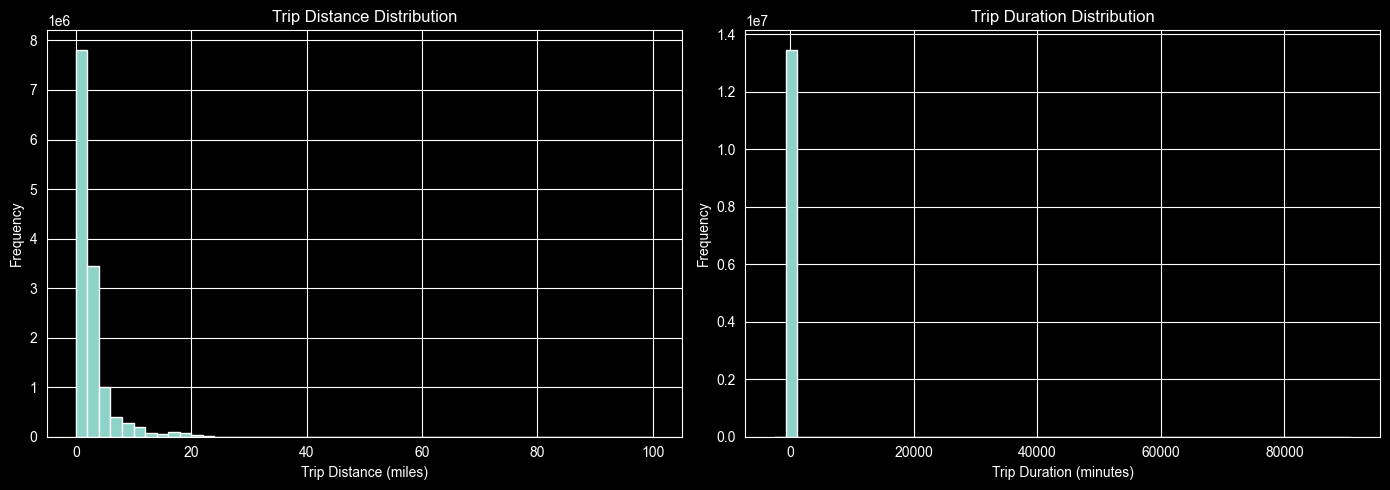

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trip distance distribution
if 'trip_distance' in trips_df.columns:
    trips_df['trip_distance'].hist(bins=50, ax=axes[0])
    axes[0].set_title("Trip Distance Distribution")
    axes[0].set_xlabel("Trip Distance (miles)")
    axes[0].set_ylabel("Frequency")

# Trip duration distribution
if {'pickup_at', 'dropoff_at'}.issubset(trips_df.columns):
    duration = (trips_df['dropoff_at'] - trips_df['pickup_at']).dt.total_seconds() / 60.0
    duration.hist(bins=50, ax=axes[1])
    axes[1].set_title("Trip Duration Distribution")
    axes[1].set_xlabel("Trip Duration (minutes)")
    axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Simple clean

In [13]:
clean_df = trips_df.copy()
initial_rows = len(clean_df)

if {'pickup_at', 'dropoff_at'}.issubset(clean_df.columns):
    clean_df = clean_df[
        clean_df['pickup_at'].notna()
        & clean_df['dropoff_at'].notna()
        & (clean_df['dropoff_at'] >= clean_df['pickup_at'])
        ]

if 'passenger_count' in clean_df.columns:
    clean_df = clean_df[clean_df['passenger_count'].between(1, 8)]

if 'trip_distance' in clean_df.columns:
    distance_outlier_mask = ~clean_df['trip_distance'].between(0, 200)
    distance_outlier_rows = distance_outlier_mask.sum()

    print(f"\nTrip distance outliers: {distance_outlier_rows:,}")

    if distance_outlier_rows > 0:
        display(clean_df.loc[distance_outlier_mask, ['trip_distance']].head(10))

    clean_df = clean_df.loc[~distance_outlier_mask].copy()
    print(f"Cleaned rows after distance cleaning: {initial_rows - len(clean_df):,}")

if {'pickup_at', 'dropoff_at'}.issubset(clean_df.columns):
    clean_df['trip_duration_min'] = (
            (clean_df['dropoff_at'] - clean_df['pickup_at']).dt.total_seconds() / 60.0
    )

    duration_outlier_mask = ~clean_df['trip_duration_min'].between(1, 300)
    duration_outlier_rows = duration_outlier_mask.sum()

    print(f"\nTrip duration outliers: {duration_outlier_rows:,}")

    if duration_outlier_rows > 0:
        display(
            clean_df.loc[
                duration_outlier_mask,
                ['pickup_at', 'dropoff_at', 'trip_duration_min', 'trip_distance']
            ].head(10)
        )

    clean_df = clean_df.loc[~duration_outlier_mask].copy()
    print(f"Cleaned rows after duration cleaning: {initial_rows - len(clean_df):,}")

if 'pickup_at' in clean_df.columns:
    clean_df['pickup_hour'] = clean_df['pickup_at'].dt.hour
    clean_df['pickup_weekday'] = clean_df['pickup_at'].dt.weekday

print(f"Initial rows: {initial_rows:,}")
print(f"Final rows:   {len(clean_df):,}")
clean_df.head()


Trip distance outliers: 0
Cleaned rows after distance cleaning: 72,081

Trip duration outliers: 57,072


,pickup_at,dropoff_at,trip_duration_min,trip_distance
4,2011-01-01 00:08:00,2011-01-01 00:08:00,0.000000,0.0
5,2011-01-01 00:23:00,2011-01-01 00:23:00,0.000000,0.0
6,2011-01-01 00:25:00,2011-01-01 00:25:00,0.000000,0.0
49,2011-01-01 00:14:57,2011-01-01 00:15:56,0.983333,0.4
181,2011-01-01 00:33:35,2011-01-01 00:34:29,0.900000,0.2
344,2011-01-01 00:24:01,2011-01-01 00:24:45,0.733333,0.0
554,2011-01-01 00:51:39,2011-01-01 00:52:26,0.783333,0.0
636,2011-01-01 00:56:27,2011-01-01 00:57:24,0.950000,0.0
904,2011-01-01 00:11:25,2011-01-01 00:11:25,0.000000,17.6
930,2011-01-01 00:06:12,2011-01-01 00:06:45,0.550000,0.1


Cleaned rows after duration cleaning: 129,153
Initial rows: 13,464,885
Final rows:   13,335,732


,pickup_at,dropoff_at,passenger_count,trip_distance,pickup_location_id,dropoff_location_id,trip_duration_min,pickup_hour,pickup_weekday
0,2011-01-01 00:10:00,2011-01-01 00:12:00,4,0.0,145,145,2.000000,0,5
1,2011-01-01 00:04:00,2011-01-01 00:13:00,4,0.0,264,264,9.000000,0,5
2,2011-01-01 00:14:00,2011-01-01 00:16:00,4,0.0,264,264,2.000000,0,5
3,2011-01-01 00:04:00,2011-01-01 00:06:00,5,0.0,146,146,2.000000,0,5
7,2011-01-01 00:58:10,2011-01-01 01:15:35,1,8.0,138,256,17.416667,0,5


### EDA after cleaning

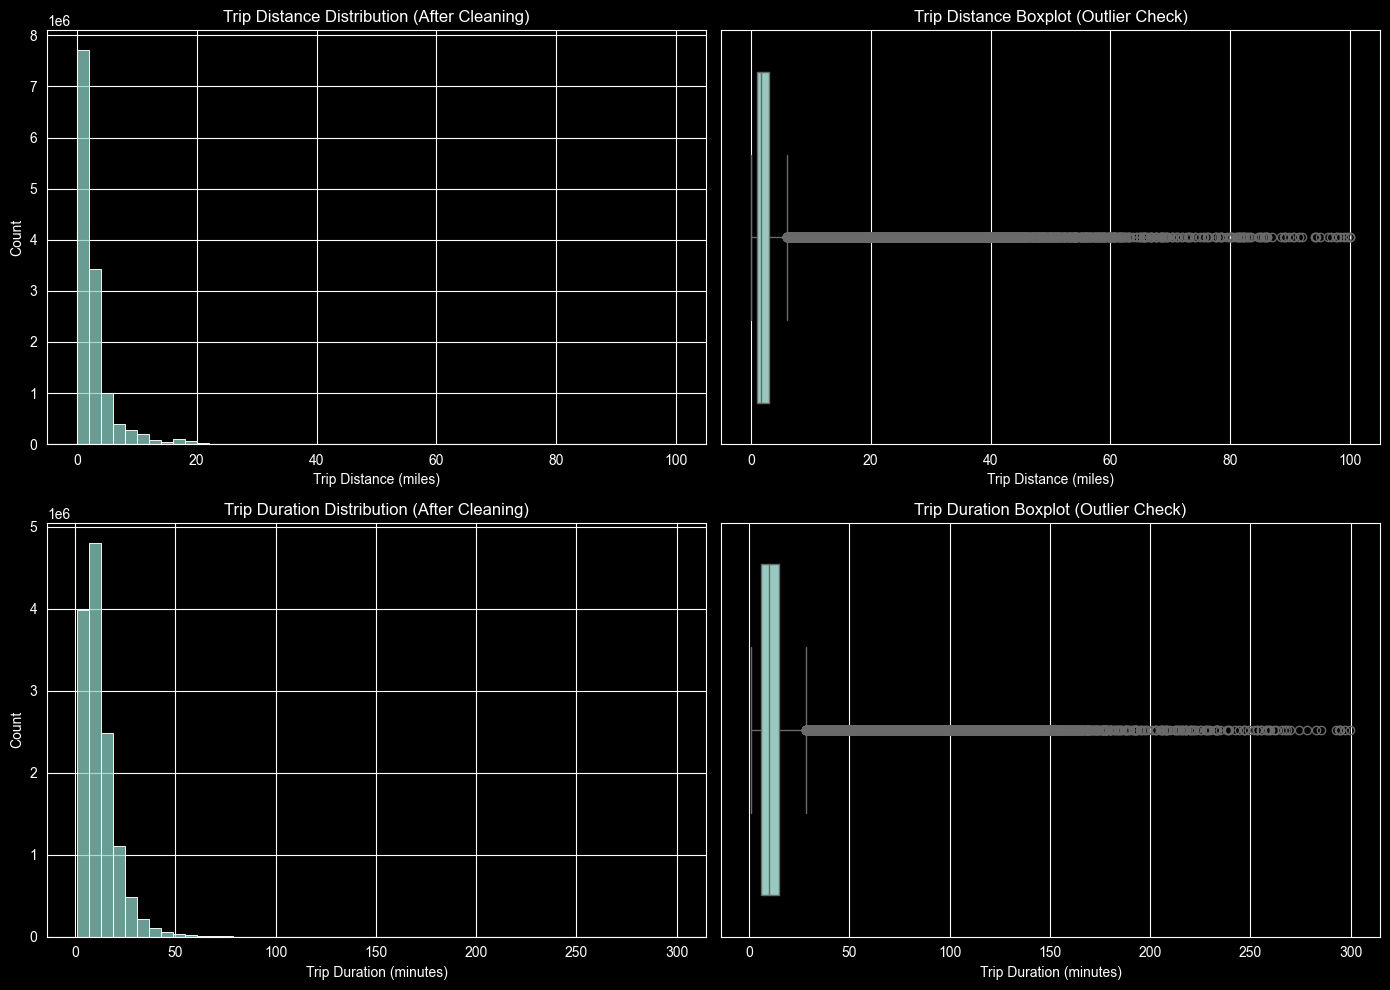

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trip distance histogram
sns.histplot(clean_df['trip_distance'], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Trip Distance Distribution (After Cleaning)")
axes[0, 0].set_xlabel("Trip Distance (miles)")

# Trip distance boxplot
sns.boxplot(x=clean_df['trip_distance'], ax=axes[0, 1])
axes[0, 1].set_title("Trip Distance Boxplot (Outlier Check)")
axes[0, 1].set_xlabel("Trip Distance (miles)")

# Trip duration histogram
sns.histplot(clean_df['trip_duration_min'], bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Trip Duration Distribution (After Cleaning)")
axes[1, 0].set_xlabel("Trip Duration (minutes)")

# Trip duration boxplot
sns.boxplot(x=clean_df['trip_duration_min'], ax=axes[1, 1])
axes[1, 1].set_title("Trip Duration Boxplot (Outlier Check)")
axes[1, 1].set_xlabel("Trip Duration (minutes)")

plt.tight_layout()
plt.show()

## Final data

In [15]:
final_df = clean_df.copy()

final_df.info()

final_df.head()

<class 'pandas.DataFrame'>
Index: 13335732 entries, 0 to 13464996
Data columns (total 9 columns):
 #   Column               Dtype         
---  ------               -----         
 0   pickup_at            datetime64[us]
 1   dropoff_at           datetime64[us]
 2   passenger_count      int64         
 3   trip_distance        float64       
 4   pickup_location_id   int64         
 5   dropoff_location_id  int64         
 6   trip_duration_min    float64       
 7   pickup_hour          int32         
 8   pickup_weekday       int32         
dtypes: datetime64[us](2), float64(2), int32(2), int64(3)
memory usage: 915.7 MB


,pickup_at,dropoff_at,passenger_count,trip_distance,pickup_location_id,dropoff_location_id,trip_duration_min,pickup_hour,pickup_weekday
0,2011-01-01 00:10:00,2011-01-01 00:12:00,4,0.0,145,145,2.000000,0,5
1,2011-01-01 00:04:00,2011-01-01 00:13:00,4,0.0,264,264,9.000000,0,5
2,2011-01-01 00:14:00,2011-01-01 00:16:00,4,0.0,264,264,2.000000,0,5
3,2011-01-01 00:04:00,2011-01-01 00:06:00,5,0.0,146,146,2.000000,0,5
7,2011-01-01 00:58:10,2011-01-01 01:15:35,1,8.0,138,256,17.416667,0,5


<Axes: >

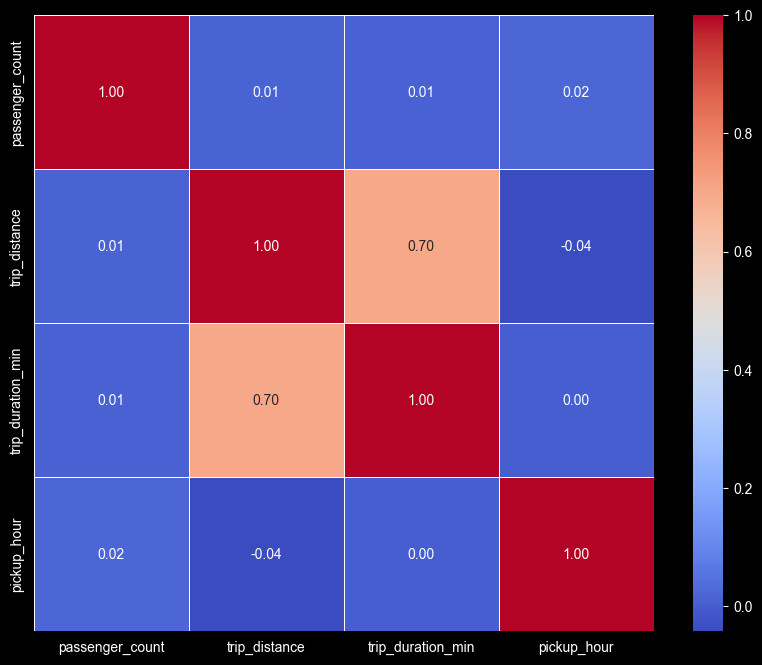

In [22]:
correlation_matrix = final_df[['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)